# ASAP8 Detection of Change analysis

Compact DoC notebook for optical-spike image variability and longitudinal image-response timing. Standalone anatomical depth analyses live in the separate depth notebook.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from matplotlib.lines import Line2D
from IPython.display import display, HTML

from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.dataset import DEPTH_GROUP_ORDER, build_voltage_session_table, build_voltage_roi_table
from vip_slap2_analysis.voltage.spikes import DETECTOR_VERSION, build_spike_table
from vip_slap2_analysis.behavior.change_detection import build_change_detection_events
from vip_slap2_analysis.voltage.responses import build_single_trial_index, load_response_package, get_mean_response, get_sequence_response, load_single_trial_traces
from vip_slap2_analysis.behavior.encoder import compute_encoder_velocity

assert DETECTOR_VERSION == "template_v1"
sns.set_style("white")
plt.rcParams.update({"legend.fontsize":"x-large","axes.labelsize":"xx-large","axes.titlesize":"xx-large","xtick.labelsize":"xx-large","ytick.labelsize":"xx-large"})
display(HTML("<style>.container { width:100% !important; }</style>"))

# 1. Setup
## Configuration

In [2]:
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")
SAVE_PATH = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots")
TARGET_MICE = [852835, 863774]
TARGET_SESSION_LABELS = None
TARGET_SESSION_IDS = None
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
TRACE_VARIANT = "dff_robust_f0_trial"
REGISTRATION_FILENAME = "roi_identity_registration.csv"
EXCLUDE_INVALID_ROIS = True
EXPECTED_F0_SMOOTH_SEC = 60.0
FORCE_SPIKE_RECOMPUTE = False
SPIKE_KWARGS = dict(height_sigma=3.0, template_sigma=3.5, prominence_sigma=0.5)
RUNNING_KWARGS = dict(wheel_radius_cm=4.69, encoder_units="ticks", ticks_per_revolution=8192, absolute_velocity=True)

SESSION_ORDER = ["A0","A1","A2","B0","B1","B2"]
IMAGE_WINDOW_S = (0.0, 0.25)
IMAGE_CYCLE_S = 0.75
MIN_TRIALS_PER_IMAGE = 5
PEAK_WINDOW_S = (-0.25, 0.50)
PEAK_SMOOTH_MS = 10.0
DEPTH_COLORS = {"<100 µm":"#EBA287","100–150 µm":"#d1e2b0",">150 µm":"#7bbcd5"}
def depth_group_from_um(depth):
    depth=float(depth)
    return "<100 µm" if depth < 100 else ("100–150 µm" if depth <= 150 else ">150 µm")

## Canonical DoC tables

In [3]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)
sessions = build_voltage_session_table(registry, subject_ids=TARGET_MICE, paradigms=PARADIGMS, exclude_session_types=EXCLUDE_SESSION_TYPES, session_labels=TARGET_SESSION_LABELS, session_ids=TARGET_SESSION_IDS, trace_variant=TRACE_VARIANT, expected_f0_smooth_sec=EXPECTED_F0_SMOOTH_SEC)
rois = build_voltage_roi_table(sessions, registration_filename=REGISTRATION_FILENAME, exclude_invalid_rois=EXCLUDE_INVALID_ROIS)
rois["depth_um"] = pd.to_numeric(rois["depth_um"], errors="coerce")
rois["depth_group"] = rois["depth_um"].map(depth_group_from_um)
spikes = build_spike_table(sessions, rois, force=FORCE_SPIKE_RECOMPUTE, detection_kwargs=SPIKE_KWARGS)
events = build_change_detection_events(sessions)
trial_index = build_single_trial_index(sessions, events)

print(f"{len(sessions)} sessions · {rois['included'].sum()} included ROI observations · {len(spikes):,} spikes · {len(events):,} image cycles")
display(sessions[["subject_id","session_id","session_label","session_order","dmd1_depth_um","dmd2_depth_um"]])
display(rois.loc[rois["included"],["subject_id","session_label","dmd","roi","depth_um","depth_group"]].drop_duplicates().sort_values(["depth_um","subject_id","session_label"]))

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\voltage\dataset.py:203: UserWarning: 852835_2026-07-24_12-13-41: F0 smoother is 10 s, expected 60 s
  warnings.warn(


13 sessions · 99 included ROI observations · 1,039,642 spikes · 29,797 image cycles


,subject_id,session_id,session_label,session_order,dmd1_depth_um,dmd2_depth_um
0,852835,852835_2026-07-23_14-27-27,A0,0,46.75,120.50
1,852835,852835_2026-07-24_12-13-41,A1,1,51.00,125.50
2,852835,852835_2026-07-27_11-59-54,A2,2,60.50,133.00
3,852835,852835_2026-07-28_17-13-56,B0,3,52.75,125.62
4,852835,852835_2026-07-29_10-08-37,B1,4,60.00,133.25
5,852835,852835_2026-07-30_15-04-34,B2,5,57.88,128.62
6,852835,852835_2026-08-01_14-58-35,G1,6,60.75,104.38
7,863774,863774_2026-08-04_08-12-47,A0,0,190.38,109.62
8,863774,863774_2026-08-05_13-17-41,A1,1,197.88,120.00
9,863774,863774_2026-08-06_09-15-41,A2,2,199.88,121.62


,subject_id,session_label,dmd,roi,depth_um,depth_group
0,852835,A0,1,0,46.75,<100 µm
1,852835,A0,1,1,46.75,<100 µm
2,852835,A0,1,2,46.75,<100 µm
3,852835,A0,1,3,46.75,<100 µm
7,852835,A1,1,0,51.00,<100 µm
...,...,...,...,...,...,...
81,863774,B0,1,3,204.38,>150 µm
96,863774,B2,1,0,207.38,>150 µm
97,863774,B2,1,1,207.38,>150 µm
98,863774,B2,1,2,207.38,>150 µm


# 2. Image responses
## Image-response peak latency

In [4]:
def smooth_finite(y, sigma):
    y = np.asarray(y,float).reshape(-1); good = np.isfinite(y)
    if good.sum() < 3: return np.full_like(y,np.nan)
    y = np.interp(np.arange(y.size),np.flatnonzero(good),y[good])
    return ndimage.gaussian_filter1d(y,sigma,mode="nearest")

selected = sessions[sessions["session_label"].astype(str).isin(SESSION_ORDER)]
available_labels = [s for s in SESSION_ORDER if s in set(selected["session_label"].astype(str))]
rows = []
for session in selected.itertuples(index=False):
    sid = str(session.session_id); pkg = load_response_package(session.mean_npz)
    for r in rois[(rois["session_id"].astype(str)==sid) & rois["included"].astype(bool)].itertuples(index=False):
        dmd, roi, key = int(r.dmd), int(r.roi), f"DMD{int(r.dmd)}"
        if key not in pkg: continue
        for image in pkg[key].get("image_identity",{}):
            try: t,y = get_mean_response(pkg,dmd=dmd,source_roi=roi,event_type="image",image_name=image)
            except (KeyError,IndexError,ValueError): continue
            t,y = np.asarray(t,float).reshape(-1),np.asarray(y,float).squeeze()
            if y.ndim != 1 or len(y) != len(t) or len(y) < 3: continue
            dt = np.nanmedian(np.diff(t))
            if not np.isfinite(dt) or dt <= 0: continue
            ys = smooth_finite(y,(PEAK_SMOOTH_MS/1000)/dt)
            keep = (t>=PEAK_WINDOW_S[0]) & (t<=PEAK_WINDOW_S[1]) & np.isfinite(ys)
            if not keep.any(): continue
            idx = np.flatnonzero(keep); p = idx[np.nanargmax(ys[keep])]
            rows.append(dict(subject_id=str(r.subject_id),session_id=sid,session_label=str(r.session_label),cell_id=str(r.cell_id),global_cell_id=str(getattr(r,"global_cell_id","")),manually_registered=bool(getattr(r,"manually_registered",False)),depth_um=float(r.depth_um),depth_group=str(r.depth_group),image_name=str(image),peak_latency_s=float(t[p]),peak_dff=float(ys[p])))

image_peak_latency = pd.DataFrame(rows)
if image_peak_latency.empty: raise RuntimeError("No image-response peaks extracted.")
keys = ["subject_id","session_id","session_label","cell_id","global_cell_id","manually_registered"]
cell_session_peak = image_peak_latency.groupby(keys,observed=True,dropna=False).agg(peak_latency_s=("peak_latency_s","median"),peak_latency_q25_s=("peak_latency_s",lambda x:np.nanquantile(x,.25)),peak_latency_q75_s=("peak_latency_s",lambda x:np.nanquantile(x,.75)),n_images=("image_name","nunique"),depth_um=("depth_um","median")).reset_index()
cell_session_peak["depth_group"] = np.select([cell_session_peak["depth_um"]<100,cell_session_peak["depth_um"]>150],["<100 µm",">150 µm"],default="100–150 µm")
tracked_peak = cell_session_peak[cell_session_peak["manually_registered"]].groupby(["subject_id","global_cell_id"],group_keys=False,observed=True).filter(lambda x:x["session_id"].nunique()>=2)

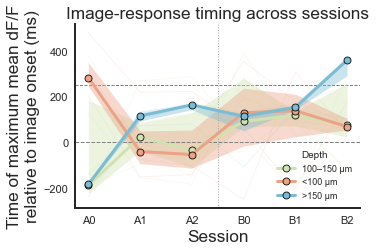

In [5]:
def finish_axis(ax):
    sns.despine(ax=ax); ax.tick_params(axis="both",labelsize=11)
    for spine in ax.spines.values(): spine.set_linewidth(2)

xmap = {s:i for i,s in enumerate(available_labels)}; x = np.arange(len(available_labels))
fig,ax = plt.subplots(figsize=(5.2,3.6))
for (_,cell),g in tracked_peak.groupby(["subject_id","global_cell_id"],observed=True):
    g = g.assign(x=g["session_label"].map(xmap)).dropna(subset=["x"]).sort_values("x")
    if len(g)>1: ax.plot(g["x"],1000*g["peak_latency_s"],color=DEPTH_COLORS[str(g["depth_group"].iloc[0])],lw=.8,alpha=.16,zorder=1)
for group,g in tracked_peak.groupby("depth_group",observed=True):
    q = g.groupby("session_label")["peak_latency_s"].agg(median="median",q25=lambda z:np.nanquantile(z,.25),q75=lambda z:np.nanquantile(z,.75)).reindex(available_labels)
    valid=q["median"].notna().to_numpy(); xx=x[valid]; c=DEPTH_COLORS[str(group)]
    ax.fill_between(xx,1000*q["q25"].to_numpy()[valid],1000*q["q75"].to_numpy()[valid],color=c,alpha=.4,lw=0)
    ax.plot(xx,1000*q["median"].to_numpy()[valid],"-o",color=c,lw=3,ms=7,mec="black",mew=.8,label=str(group),zorder=3)
ax.axhline(0,color=".5",lw=1,ls="--")
if "A2" in xmap and "B0" in xmap: ax.axvline((xmap["A2"]+xmap["B0"])/2,color=".65",lw=1,ls=":")
ax.set(xticks=x,xticklabels=available_labels,xlabel="Session",ylabel="Time of maximum mean dF/F\nrelative to image onset (ms)",
#        ylim=(1000*PEAK_WINDOW_S[0],1000*PEAK_WINDOW_S[1]),
       title="Image-response timing across sessions")
ax.axhline(250,color='k',lw=0.5,dashes=[6,3],zorder=0)
finish_axis(ax); ax.legend(title="Depth",frameon=False,fontsize=9); fig.tight_layout()
save_figure(fig,os.path.join(SAVE_PATH,"latency_shift"),formats=[".pdf"],dpi=300); plt.show()

In [108]:
# Mean image response for each neuron
## show 6 plots (2 rows, 3 col) of A0->B2 mean image respose for all neurons + depth group averages

In [110]:
# A2-A0, B2-B0 difference line plots. 
## For each neuron and depth group, 
## plot the difference in dFF between first and last image days for each session type

## Trial-wise image variability
Ordinary image presentations use 0–250 ms firing rate. `RMS²` is trial-count-weighted between-image firing-rate variance; `FVE = RMS² / total firing-rate variance`.

In [6]:
ordinary_events = events[events["retained_image_window"].astype(bool) & ~events["is_change"].astype(bool) & ~events["is_omission"].astype(bool) & events["image_label"].notna()].copy()
spike_lookup = {(str(sid),int(dmd),int(roi)):np.sort(g["spike_time_sec"].to_numpy(float)) for (sid,dmd,roi),g in spikes.groupby(["session_id","dmd","roi"],observed=True)}
trial_rows=[]; start,stop=IMAGE_WINDOW_S; duration=stop-start
for session in sessions.itertuples(index=False):
    sid=str(session.session_id); ev=ordinary_events[ordinary_events["session_id"].astype(str)==sid][["event_id","onset_sec","image_label","time_block"]]
    onsets=ev["onset_sec"].to_numpy(float)
    for r in rois[(rois["session_id"].astype(str)==sid) & rois["included"].astype(bool)].itertuples(index=False):
        st=spike_lookup.get((sid,int(r.dmd),int(r.roi)),np.array([],float))
        rate=(np.searchsorted(st,onsets+stop,side="left")-np.searchsorted(st,onsets+start,side="left"))/duration
        t=ev.copy(); t["image_rate_hz"]=rate; t["subject_id"]=str(r.subject_id); t["session_id"]=sid; t["session_label"]=str(r.session_label); t["session_order"]=int(r.session_order); t["dmd"]=int(r.dmd); t["roi"]=int(r.roi); t["cell_id"]=str(r.cell_id); t["global_cell_id"]=str(getattr(r,"global_cell_id","")); t["manually_registered"]=bool(getattr(r,"manually_registered",False)); t["depth_um"]=float(r.depth_um); t["depth_group"]=str(r.depth_group)
        trial_rows.append(t)
image_trial_df=pd.concat(trial_rows,ignore_index=True)

metric_keys=["subject_id","session_id","session_label","session_order","dmd","roi","cell_id","global_cell_id","manually_registered","depth_um","depth_group"]
metric_rows=[]
for keys,t in image_trial_df.groupby(metric_keys,observed=True,dropna=False):
    counts=t["image_label"].value_counts(); keep=counts[counts>=MIN_TRIALS_PER_IMAGE].index; q=t[t["image_label"].isin(keep)]
    y=q["image_rate_hz"].to_numpy(float)
    if len(y)<2 or q["image_label"].nunique()<2: continue
    grand=y.mean(); total=np.mean((y-grand)**2); means=q.groupby("image_label")["image_rate_hz"].agg(["mean","size"])
    between=float(np.sum(means["size"]*(means["mean"]-grand)**2)/len(y))
    row=dict(zip(metric_keys,keys)); row.update(mean_rate_hz=float(grand),total_rate_variance_hz2=float(total),identity_rate_variance_hz2=between,image_rms_hz=float(np.sqrt(between)),image_fve=float(between/total) if total>0 else np.nan,n_trials=int(len(y)),n_images=int(len(means)))
    metric_rows.append(row)
image_metrics=pd.DataFrame(metric_rows)
registered_metrics=image_metrics[image_metrics["manually_registered"]].copy()
cell_metrics=registered_metrics.groupby(["subject_id","global_cell_id","depth_group"],observed=True).agg(depth_um=("depth_um","median"),total_rate_variance_hz2=("total_rate_variance_hz2","median"),image_fve=("image_fve","median"),image_rms_hz=("image_rms_hz","median"),n_sessions=("session_id","nunique")).reset_index()
display(image_metrics.head())

,subject_id,session_id,session_label,session_order,dmd,roi,cell_id,global_cell_id,manually_registered,depth_um,depth_group,mean_rate_hz,total_rate_variance_hz2,identity_rate_variance_hz2,image_rms_hz,image_fve,n_trials,n_images
0,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,<100 µm,6.475728,49.925139,0.321660,0.567151,0.006443,2060,8
1,852835,852835_2026-07-23_14-27-27,A0,0,1,1,852835_C002,852835_C002,True,46.75,<100 µm,6.324272,63.778343,0.386275,0.621510,0.006057,2060,8
2,852835,852835_2026-07-23_14-27-27,A0,0,1,2,852835_C001,852835_C001,True,46.75,<100 µm,6.417476,110.062607,1.703853,1.305317,0.015481,2060,8
3,852835,852835_2026-07-23_14-27-27,A0,0,1,3,852835_C000,852835_C000,True,46.75,<100 µm,5.524272,56.558149,0.454689,0.674306,0.008039,2060,8
4,852835,852835_2026-07-23_14-27-27,A0,0,2,0,852835_C006,852835_C006,True,120.50,100–150 µm,15.477670,143.657268,1.306179,1.142882,0.009092,2060,8


In [7]:
def plot_longitudinal(ax,df,metric,ylabel,ylim=None):
    labels=[s for s in SESSION_ORDER if s in set(df["session_label"].astype(str))]
    xm={s:i for i,s in enumerate(labels)}; xx=np.arange(len(labels))
    tracked=df[
        df["manually_registered"].astype(bool)
        & df["global_cell_id"].astype(str).ne("")
        & df["global_cell_id"].astype(str).ne("nan")
    ].copy()
    tracked=tracked.groupby(
        ["subject_id","global_cell_id"],group_keys=False,observed=True
    ).filter(lambda z:z["session_id"].nunique()>=2)
    for (_,cell),g in tracked.groupby(["subject_id","global_cell_id"],observed=True):
        g=g.assign(x=g["session_label"].map(xm)).dropna(subset=["x"]).sort_values("x")
        if len(g)>1:
            ax.plot(
                g["x"],g[metric],color=DEPTH_COLORS[str(g["depth_group"].iloc[0])],
                lw=.8,alpha=.12,zorder=1
            )
    for group,g in df.groupby("depth_group",observed=True):
        q=g.groupby("session_label")[metric].agg(
            median="median",
            q25=lambda z:np.nanquantile(z,.25),
            q75=lambda z:np.nanquantile(z,.75),
        ).reindex(labels)
        valid=q["median"].notna().to_numpy(); xq=xx[valid]
        if not valid.any(): continue
        c=DEPTH_COLORS[str(group)]
        ax.fill_between(
            xq,q["q25"].to_numpy()[valid],q["q75"].to_numpy()[valid],
            color=c,alpha=.12,lw=0,zorder=2
        )
        ax.plot(
            xq,q["median"].to_numpy()[valid],"-o",color=c,ms=7,
            mec="black",mew=.8,lw=3,zorder=3,label=str(group)
        )
    if "A2" in xm and "B0" in xm:
        ax.axvline((xm["A2"]+xm["B0"])/2,color=".65",lw=1,ls=":")
    ax.set(xticks=xx,xticklabels=labels,xlabel="Session",ylabel=ylabel)
    finish_axis(ax)

def add_depth_legend(ax,loc="best"):
    ax.legend(
        handles=[
            Line2D([0],[0],color=DEPTH_COLORS[g],lw=3,marker="o",
                   mec="black",mew=.6,label=g)
            for g in DEPTH_GROUP_ORDER
        ],
        title="Depth",frameon=False,fontsize=9,loc=loc
    )

def roi_number(x):
    if isinstance(x,str):
        hits=re.findall(r"\d+",x)
        if not hits:
            raise ValueError(f"Could not parse ROI label {x!r}")
        return int(hits[-1])
    return int(x)

def select_roi_example(spec):
    roi=roi_number(spec["roi"])
    q=rois[
        rois["included"].astype(bool)
        & rois["subject_id"].astype(str).eq(str(spec["mouse"]))
        & rois["session_label"].astype(str).eq(str(spec["day"]))
        & rois["dmd"].astype(int).eq(int(spec["dmd"]))
        & rois["roi"].astype(int).eq(roi)
    ]
    if q.empty:
        avail=rois[
            rois["included"].astype(bool)
            & rois["subject_id"].astype(str).eq(str(spec["mouse"]))
            & rois["session_label"].astype(str).eq(str(spec["day"]))
        ][["dmd","roi"]].drop_duplicates().values.tolist()
        raise ValueError(
            f"No included ROI matches {spec}. "
            f"Available DMD/ROI pairs for this mouse/day: {avail}"
        )
    r=q.iloc[0]
    s=sessions[sessions["session_id"].astype(str).eq(str(r["session_id"]))].iloc[0]
    return r,s

def decode_strings(values):
    return np.asarray([
        x.decode() if isinstance(x,(bytes,np.bytes_)) else str(x)
        for x in np.asarray(values).reshape(-1)
    ])

def source_roi_axis(package,dmd,source_roi):
    ids=decode_strings(package[f"DMD{int(dmd)}"]["roi_ids"])
    label=f"DMD{int(dmd)}_ROI{int(source_roi)}"
    hits=np.flatnonzero(ids==label)
    if not len(hits):
        parsed=np.array([int(re.findall(r"\d+",x)[-1]) for x in ids],int)
        hits=np.flatnonzero(parsed==int(source_roi))
    if not len(hits):
        raise KeyError(f"{label} is absent from the kept ROI axis")
    return int(hits[0])

def match_image_key(dmd_pkg,image):
    image=str(image); stem=Path(image.replace("\\","/")).stem
    return next(
        (k for k in dmd_pkg.get("image_identity",{})
         if str(k)==image or Path(str(k).replace("\\","/")).stem==stem),
        None,
    )

def reconcile_local_timebase(t,n_samples):
    t=np.asarray(t,float).reshape(-1)
    if len(t)==n_samples:
        return t
    if len(t)<2:
        raise ValueError(f"Cannot reconcile {len(t)}-sample stored timebase to {n_samples} trace samples.")
    dt=float(np.nanmedian(np.diff(t)))
    if not np.isfinite(dt) or dt<=0:
        raise ValueError("Stored event timebase has invalid sample spacing.")
    zero=int(np.nanargmin(np.abs(t)))
    zero=min(zero,n_samples-1)
    return (np.arange(n_samples,dtype=float)-zero)*dt

def mean_single_trial_dff(session,dmd,roi,event_type):
    """Mean ± SEM dF/F from the derived single-trial H5 for change/omission examples."""
    path=Path(session["single_trial_h5"])
    with h5py.File(path,"r") as h5:
        group=h5[f"DMD{int(dmd)}"]
        ids=decode_strings(group["roi_ids"][:])
        label=f"DMD{int(dmd)}_ROI{int(roi)}"
        hits=np.flatnonzero(ids==label)
        if not len(hits):
            parsed=np.array([int(re.findall(r"\d+",x)[-1]) for x in ids],int)
            hits=np.flatnonzero(parsed==int(roi))
        if not len(hits):
            raise KeyError(f"{label} is absent from {path}")
        axis=int(hits[0])
        traces=np.asarray(group[event_type]["traces"][:,axis,:],float)
        t=reconcile_local_timebase(h5[f"timebase_sec/{event_type}"][:],traces.shape[-1])
    mean=np.nanmean(traces,axis=0)
    n=np.sum(np.isfinite(traces),axis=0)
    sem=np.nanstd(traces,axis=0,ddof=1)/np.sqrt(np.maximum(n,1))
    sem[n<2]=np.nan
    return t,mean,sem,traces.shape[0]


C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_25484\2262535709.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cell_metrics,x="depth_group",y="total_rate_variance_hz2",order=order,palette=DEPTH_COLORS,inner=None,width=.5,linewidth=1.5,ax=axs[0])


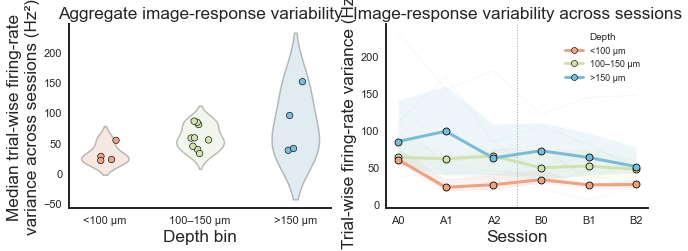

In [8]:
fig,axs=plt.subplots(1,2,figsize=(9.2,3.6))
order=[g for g in DEPTH_GROUP_ORDER if g in set(cell_metrics["depth_group"].astype(str))]
sns.violinplot(data=cell_metrics,x="depth_group",y="total_rate_variance_hz2",order=order,palette=DEPTH_COLORS,inner=None,width=.5,linewidth=1.5,ax=axs[0])
for coll in axs[0].collections: coll.set_alpha(.25); coll.set_edgecolor("black")
rng=np.random.default_rng(8)
xpos=np.array([order.index(str(x)) for x in cell_metrics["depth_group"]],float)+rng.uniform(-.12,.12,len(cell_metrics))
axs[0].scatter(xpos,cell_metrics["total_rate_variance_hz2"],s=42,c=[DEPTH_COLORS[str(x)] for x in cell_metrics["depth_group"]],edgecolor="black",linewidth=.6,zorder=3)
axs[0].set(xlabel="Depth bin",ylabel="Median trial-wise firing-rate\nvariance across sessions (Hz²)",title="Aggregate image-response variability"); finish_axis(axs[0])

plot_longitudinal(axs[1],registered_metrics,"total_rate_variance_hz2","Trial-wise firing-rate variance (Hz²)")
axs[1].set_title("Image-response variability across sessions"); add_depth_legend(axs[1])
fig.tight_layout(); save_figure(fig,os.path.join(SAVE_PATH,"image_trial_variance"),formats=[".pdf"],dpi=300); plt.show()

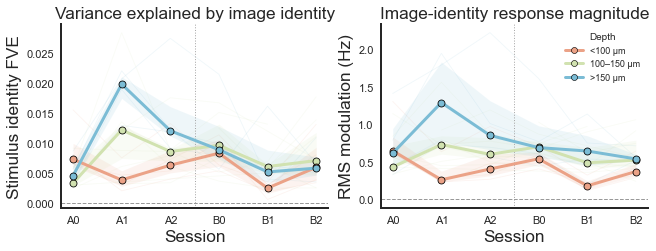

,subject_id,session_label,global_cell_id,depth_group,mean_rate_hz,total_rate_variance_hz2,identity_rate_variance_hz2,image_fve,image_rms_hz,n_trials,n_images
3,852835,A0,852835_C000,<100 µm,5.524272,56.558149,0.454689,0.008039,0.674306,2060,8
2,852835,A0,852835_C001,<100 µm,6.417476,110.062607,1.703853,0.015481,1.305317,2060,8
1,852835,A0,852835_C002,<100 µm,6.324272,63.778343,0.386275,0.006057,0.621510,2060,8
0,852835,A0,852835_C003,<100 µm,6.475728,49.925139,0.321660,0.006443,0.567151,2060,8
6,852835,A0,852835_C004,100–150 µm,3.732039,54.685478,0.349983,0.006400,0.591594,2060,8
...,...,...,...,...,...,...,...,...,...,...,...
97,863774,B2,863774_C004,100–150 µm,5.467926,60.540369,0.836173,0.013812,0.914425,2011,8
91,863774,B2,863774_C005,>150 µm,3.065142,24.840610,0.269844,0.010863,0.519465,2011,8
92,863774,B2,863774_C006,>150 µm,12.312282,146.718989,0.509696,0.003474,0.713930,2011,8
94,863774,B2,863774_C007,>150 µm,8.262556,53.762989,0.266696,0.004961,0.516426,2011,8


In [85]:
fig,axs=plt.subplots(1,2,figsize=(9.2,3.6))
plot_longitudinal(axs[0],registered_metrics,"image_fve","Stimulus identity FVE")
plot_longitudinal(axs[1],registered_metrics,"image_rms_hz","RMS modulation (Hz)")
axs[0].axhline(0,color=".6",lw=1,ls="--"); axs[1].axhline(0,color=".6",lw=1,ls="--")
axs[0].set_title("Variance explained by image identity"); axs[1].set_title("Image-identity response magnitude")
add_depth_legend(axs[1]); fig.tight_layout()
save_figure(fig,os.path.join(SAVE_PATH,"image_identity_fve_rms"),formats=[".pdf"],dpi=300); plt.show()
display(
    image_metrics
    .sort_values(["subject_id","session_order","depth_um","global_cell_id"])
    [["subject_id","session_label","global_cell_id","depth_group","mean_rate_hz","total_rate_variance_hz2","identity_rate_variance_hz2","image_fve","image_rms_hz","n_trials","n_images"]]
)

# 3. Image-sequence dynamics
Slope is fit to mean 0–250 ms firing rate across the first six presented images after a change; sequences are truncated at the first omission.

In [93]:
MAX_SEQUENCE_PRESENTATIONS = 12
MIN_EPOCHS_PER_POSITION = 0
MIN_SEQUENCE_POSITIONS = 4
REQUIRE_COMPLETE_SEQUENCE_BLOCK = False
PREFERRED_SLOPE_MODE = "max"   # largest signed slope on A0 or B0

In [94]:
seq_events=[]
for sid,g in events.sort_values(["session_id","event_id"]).groupby("session_id",observed=True):
    q=g.copy(); q["change_epoch"]=q["is_change"].astype(bool).cumsum()
    targets=q.loc[q["is_change"].astype(bool) & q["image_label"].notna(),["change_epoch","image_label"]].drop_duplicates("change_epoch").set_index("change_epoch")["image_label"]
    q["sequence_image"]=q["change_epoch"].map(targets)
    q["presented_target"]=(~q["is_omission"].astype(bool)) & q["image_label"].eq(q["sequence_image"]) & q["sequence_image"].notna()
    q["sequence_position"]=q.groupby("change_epoch",observed=True)["presented_target"].cumsum()
    q["omission_before"]=q.groupby("change_epoch",observed=True)["is_omission"].transform(lambda x:x.astype(bool).shift(fill_value=False).cummax())
    q=q[(q["change_epoch"]>0) & q["retained_image_window"].astype(bool) & q["presented_target"] & ~q["omission_before"] & q["sequence_position"].between(1,MAX_SEQUENCE_PRESENTATIONS)]
    seq_events.append(q[["subject_id","session_id","session_label","session_order","event_id","onset_sec","change_epoch","sequence_image","sequence_position"]])
sequence_events=pd.concat(seq_events,ignore_index=True)

seq_trials=[]
for session in sessions[sessions["session_label"].astype(str).isin(SESSION_ORDER)].itertuples(index=False):
    sid=str(session.session_id); ev=sequence_events[sequence_events["session_id"].astype(str)==sid].copy(); onsets=ev["onset_sec"].to_numpy(float)
    for r in rois[(rois["session_id"].astype(str)==sid) & rois["included"].astype(bool)].itertuples(index=False):
        st=spike_lookup.get((sid,int(r.dmd),int(r.roi)),np.array([],float))
        evr=ev.copy(); evr["sequence_rate_hz"]=(np.searchsorted(st,onsets+IMAGE_WINDOW_S[1],side="left")-np.searchsorted(st,onsets+IMAGE_WINDOW_S[0],side="left"))/(IMAGE_WINDOW_S[1]-IMAGE_WINDOW_S[0])
        evr["dmd"]=int(r.dmd); evr["roi"]=int(r.roi); evr["cell_id"]=str(r.cell_id); evr["global_cell_id"]=str(getattr(r,"global_cell_id","")); evr["manually_registered"]=bool(getattr(r,"manually_registered",False)); evr["depth_um"]=float(r.depth_um); evr["depth_group"]=str(r.depth_group)
        seq_trials.append(evr)
sequence_trial_df=pd.concat(seq_trials,ignore_index=True)

seq_keys=["subject_id","session_id","session_label","session_order","dmd","roi","cell_id","global_cell_id","manually_registered","depth_um","depth_group","sequence_image","sequence_position"]
sequence_position_df=(sequence_trial_df.groupby(seq_keys,observed=True,dropna=False)
    .agg(mean_rate_hz=("sequence_rate_hz","mean"),sem_rate_hz=("sequence_rate_hz",lambda x:np.nanstd(x,ddof=1)/np.sqrt(np.isfinite(x).sum()) if np.isfinite(x).sum()>1 else np.nan),n_epochs=("change_epoch","nunique"))
    .reset_index())
sequence_position_df=sequence_position_df[sequence_position_df["n_epochs"]>=MIN_EPOCHS_PER_POSITION]

slope_keys=["subject_id","session_id","session_label","session_order","dmd","roi","cell_id","global_cell_id","manually_registered","depth_um","depth_group","sequence_image"]
rows=[]
for keys,g in sequence_position_df.groupby(slope_keys,observed=True,dropna=False):
    g=g.sort_values("sequence_position")
    if len(g)<MIN_SEQUENCE_POSITIONS or 1 not in set(g["sequence_position"]): continue
    x=g["sequence_position"].to_numpy(float); y=g["mean_rate_hz"].to_numpy(float); slope,intercept=np.polyfit(x,y,1); pred=intercept+slope*x
    ss_res=np.sum((y-pred)**2); ss_tot=np.sum((y-y.mean())**2)
    row=dict(zip(slope_keys,keys)); row.update(sequence_slope_hz_per_presentation=float(slope),sequence_intercept_hz=float(intercept),sequence_r2=float(1-ss_res/ss_tot) if ss_tot>0 else np.nan,n_positions=int(len(g)),min_epochs_per_position=int(g["n_epochs"].min()),rate_first_hz=float(g.iloc[0]["mean_rate_hz"]),rate_last_hz=float(g.iloc[-1]["mean_rate_hz"]))
    rows.append(row)
sequence_slopes=pd.DataFrame(rows)
print(f"{len(sequence_events):,} sequence presentations · {len(sequence_slopes):,} neuron × image × session slopes")
display(sequence_slopes.head())

27,019 sequence presentations · 744 neuron × image × session slopes


,subject_id,session_id,session_label,session_order,dmd,roi,cell_id,global_cell_id,manually_registered,depth_um,depth_group,sequence_image,sequence_slope_hz_per_presentation,sequence_intercept_hz,sequence_r2,n_positions,min_epochs_per_position,rate_first_hz,rate_last_hz
0,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,<100 µm,imk00459,0.097801,6.494961,0.042761,12,2,5.714286,6.000000
1,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,<100 µm,imk00895,0.138493,6.238141,0.207160,12,6,6.315789,8.000000
2,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,<100 µm,imk00942,0.085452,6.357509,0.025268,12,7,6.555556,4.571429
3,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,<100 µm,imk01057,-0.168415,6.649327,0.075545,12,4,7.111111,9.000000
4,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,<100 µm,imk01097,-0.206912,7.125701,0.117050,12,1,5.600000,0.000000


## Selectable sequence example

Edit `SEQUENCE_EXAMPLE` to choose the mouse, day, DMD, and ROI. `image=None` selects the image with the largest absolute sequence slope for that neuron; set an image name to override it.

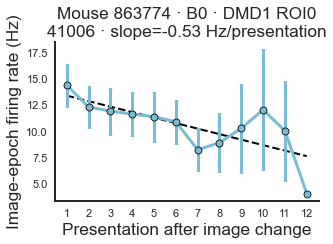

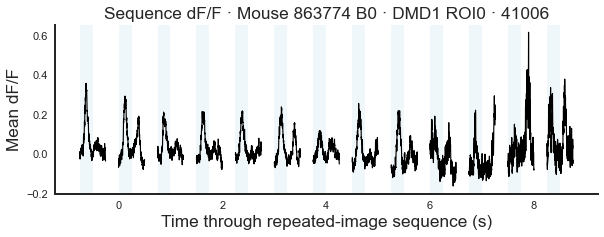

In [105]:
SEQUENCE_EXAMPLE=dict(mouse=863774,day="B0",dmd=1,roi=0,image=None)

r,s=select_roi_example(SEQUENCE_EXAMPLE)
sid=str(r["session_id"]); dmd=int(r["dmd"]); roi=int(r["roi"])
q=sequence_slopes[
    sequence_slopes["session_id"].astype(str).eq(sid)
    & sequence_slopes["dmd"].eq(dmd)
    & sequence_slopes["roi"].eq(roi)
].copy()
if q.empty:
    raise ValueError(f"No sequence slopes available for {SEQUENCE_EXAMPLE}")

if SEQUENCE_EXAMPLE["image"] is None:
    ex=q.loc[q["sequence_slope_hz_per_presentation"].abs().idxmax()]
else:
    stem=Path(str(SEQUENCE_EXAMPLE["image"]).replace("\\","/")).stem
    hit=q[q["sequence_image"].astype(str).map(
        lambda x:Path(x.replace("\\","/")).stem
    ).eq(stem)]
    if hit.empty:
        raise ValueError(
            f"Image {SEQUENCE_EXAMPLE['image']!r} not found. "
            f"Available: {q['sequence_image'].unique().tolist()}"
        )
    ex=hit.iloc[0]

m=(
    sequence_position_df["session_id"].astype(str).eq(sid)
    & sequence_position_df["dmd"].eq(dmd)
    & sequence_position_df["roi"].eq(roi)
    & sequence_position_df["sequence_image"].eq(ex["sequence_image"])
)
mean_ex=sequence_position_df[m].sort_values("sequence_position")
c=DEPTH_COLORS[str(r["depth_group"])]

fig,ax=plt.subplots(figsize=(4.5,3.5))
ax.errorbar(
    mean_ex["sequence_position"],mean_ex["mean_rate_hz"],
    yerr=mean_ex["sem_rate_hz"],fmt="o-",color=c,lw=3,ms=7,
    mec="black",mew=.8,capsize=2,zorder=3
)
xx=np.array([mean_ex["sequence_position"].min(),mean_ex["sequence_position"].max()])
ax.plot(
    xx,ex["sequence_intercept_hz"]+ex["sequence_slope_hz_per_presentation"]*xx,
    color="black",lw=2,ls="--"
)
image_display=Path(str(ex["sequence_image"]).replace("\\","/")).stem
ax.set(
    xlabel="Presentation after image change",
    ylabel="Image-epoch firing rate (Hz)",
    title=(
        f'Mouse {r["subject_id"]} · {r["session_label"]} · DMD{dmd} ROI{roi}\n'
        f'{image_display} · slope={ex["sequence_slope_hz_per_presentation"]:.2f} Hz/presentation'
    ),
)
ax.set_xticks(range(1,MAX_SEQUENCE_PRESENTATIONS+1))
finish_axis(ax); fig.tight_layout()
save_figure(fig,os.path.join(SAVE_PATH,"sequence_example_roi"),formats=[".pdf"],dpi=300)
plt.show()

# Data-club-style fluorescence sequence: concatenate the mean image-aligned
# response for each repeated-image position across the 750-ms image cycle.
pkg=load_response_package(s["sequence_npz"])
dpkg=pkg[f"DMD{dmd}"]
ikey=match_image_key(dpkg,ex["sequence_image"])
if ikey is None:
    raise KeyError(f"{ex['sequence_image']} not found in {s['sequence_npz']}")
rep=dpkg["image_identity"][ikey]["repeated"]
axis=source_roi_axis(pkg,dmd,roi)
traces=np.asarray(rep["mean"],float)[:,axis,:]
pos=np.asarray(rep["positions"],int)
counts=np.asarray(rep["counts"],int)
t=reconcile_local_timebase(pkg["timebase_sec"]["image"],traces.shape[-1])

keep=(pos<=MAX_SEQUENCE_PRESENTATIONS) & (counts>=max(1,MIN_EPOCHS_PER_POSITION))
order=np.argsort(pos[keep])
pos=pos[keep][order]; traces=traces[keep][order]

fig,ax=plt.subplots(figsize=(8.5,3.4))
for p,y in zip(pos,traces):
    local=(t>=0)&(t<IMAGE_CYCLE_S)
    tg=(p-1)*IMAGE_CYCLE_S+t[local]
    ax.plot(tg,y[local],color="black",lw=1.15)
    ax.axvspan(
        (p-1)*IMAGE_CYCLE_S,
        (p-1)*IMAGE_CYCLE_S+IMAGE_WINDOW_S[1],
        color=c,alpha=.11,lw=0
    )
ax.set(
    xlabel="Time through repeated-image sequence (s)",
    ylabel="Mean dF/F",
    title=(
        f'Sequence dF/F · Mouse {r["subject_id"]} {r["session_label"]} · '
        f'DMD{dmd} ROI{roi} · {image_display}'
    ),
)
finish_axis(ax); fig.tight_layout()
save_figure(fig,os.path.join(SAVE_PATH,"sequence_example_dff"),formats=[".pdf"],dpi=300)
plt.show()


## Sequence slope by session and depth

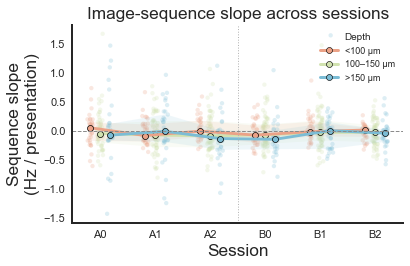

In [106]:
fig,ax=plt.subplots(figsize=(5.8,3.8)); xmap={s:i for i,s in enumerate(SESSION_ORDER)}; offsets={g:o for g,o in zip(DEPTH_GROUP_ORDER,[-.18,0,.18])}; rng=np.random.default_rng(8)
for group,g in sequence_slopes.groupby("depth_group",observed=True):
    c=DEPTH_COLORS[str(group)]
    xx=g["session_label"].map(xmap).to_numpy(float)+offsets.get(str(group),0)+rng.uniform(-.055,.055,len(g))
    ax.scatter(xx,g["sequence_slope_hz_per_presentation"],s=19,color=c,alpha=.25,edgecolor="none")
    q=g.groupby("session_label")["sequence_slope_hz_per_presentation"].agg(median="median",q25=lambda z:np.nanquantile(z,.25),q75=lambda z:np.nanquantile(z,.75)).reindex(SESSION_ORDER)
    valid=q["median"].notna().to_numpy(); xm=np.arange(len(SESSION_ORDER))[valid]+offsets.get(str(group),0)
    ax.fill_between(xm,q["q25"].to_numpy()[valid],q["q75"].to_numpy()[valid],color=c,alpha=.12,lw=0)
    ax.plot(xm,q["median"].to_numpy()[valid],"-o",color=c,lw=2.8,ms=6,mec="black",mew=.7,label=str(group))
ax.axhline(0,color=".55",lw=1,ls="--"); ax.axvline(2.5,color=".7",lw=1,ls=":")
ax.set(xticks=np.arange(len(SESSION_ORDER)),xticklabels=SESSION_ORDER,xlabel="Session",ylabel="Sequence slope\n(Hz / presentation)",title="Image-sequence slope across sessions")
finish_axis(ax); add_depth_legend(ax)
fig.tight_layout(); save_figure(fig,os.path.join(SAVE_PATH,"sequence_slopes_by_depth"),formats=[".pdf"],dpi=300); plt.show()

## Longitudinal change in each neuron's strongest image-sequence slope

In [14]:
def preferred_sequence_block(df,labels):
    start=labels[0]; q=df[df["session_label"].astype(str).isin(labels) & df["manually_registered"].astype(bool) & df["global_cell_id"].astype(str).ne("")].copy()
    s=q[q["session_label"].astype(str).eq(start)].copy()
    s["rank_value"]=s["sequence_slope_hz_per_presentation"].abs() if PREFERRED_SLOPE_MODE=="max_abs" else s["sequence_slope_hz_per_presentation"]
    pref=s.sort_values("rank_value").drop_duplicates(["subject_id","global_cell_id"],keep="last")[["subject_id","global_cell_id","sequence_image","sequence_slope_hz_per_presentation","depth_group"]].rename(columns={"sequence_image":"preferred_image","sequence_slope_hz_per_presentation":"start_slope","depth_group":"start_depth_group"})
    q=q.merge(pref,on=["subject_id","global_cell_id"],how="inner"); q=q[q["sequence_image"].eq(q["preferred_image"])]
    if REQUIRE_COMPLETE_SEQUENCE_BLOCK:
        complete=q.groupby(["subject_id","global_cell_id"],observed=True)["session_label"].nunique(); keep=complete[complete==len(labels)].index
        q=q.set_index(["subject_id","global_cell_id"]).loc[keep].reset_index() if len(keep) else q.iloc[0:0]
    q["delta_sequence_slope"]=q["sequence_slope_hz_per_presentation"]-q["start_slope"]; q["block"]=f"{labels[0]}→{labels[-1]}"
    return q

preferred_A=preferred_sequence_block(sequence_slopes,["A0","A1","A2"])
preferred_B=preferred_sequence_block(sequence_slopes,["B0","B1","B2"])
preferred_sequence_change=pd.concat([preferred_A,preferred_B],ignore_index=True)
display(preferred_sequence_change[["subject_id","global_cell_id","block","preferred_image","session_label","start_depth_group","sequence_slope_hz_per_presentation","delta_sequence_slope"]].head())

,subject_id,global_cell_id,block,preferred_image,session_label,start_depth_group,sequence_slope_hz_per_presentation,delta_sequence_slope
0,852835,852835_C000,A0→A2,imk01643,A0,<100 µm,1.105902,0.000000
1,852835,852835_C000,A0→A2,imk01643,A1,<100 µm,-0.153651,-1.259553
2,852835,852835_C000,A0→A2,imk01643,A2,<100 µm,0.016794,-1.089108
3,852835,852835_C001,A0→A2,imk01057,A0,<100 µm,1.114721,0.000000
4,852835,852835_C001,A0→A2,imk01057,A1,<100 µm,-0.167781,-1.282502


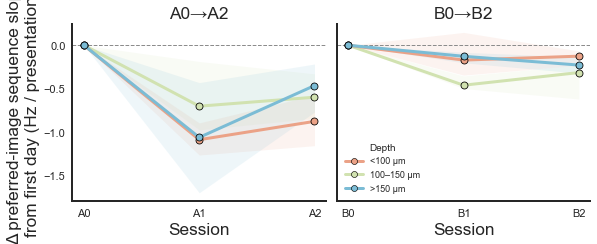

In [15]:
blocks=[("A0→A2",["A0","A1","A2"]),("B0→B2",["B0","B1","B2"])]
fig,axs=plt.subplots(1,2,figsize=(8.4,3.5),sharey=True)
for ax,(block,labels) in zip(axs,blocks):
    q=preferred_sequence_change[preferred_sequence_change["block"].eq(block)].copy(); xm={s:i for i,s in enumerate(labels)}
    for (_,cell),g in q.groupby(["subject_id","global_cell_id"],observed=True):
        g=g.assign(x=g["session_label"].map(xm)).dropna(subset=["x"]).sort_values("x"); color=DEPTH_COLORS[str(g["start_depth_group"].iloc[0])]
#         ax.plot(g["x"],g["delta_sequence_slope"],"-o",color=color,lw=1,alpha=.22,ms=4)
    for group,g in q.groupby("start_depth_group",observed=True):
        s=g.groupby("session_label")["delta_sequence_slope"].agg(median="median",q25=lambda z:np.nanquantile(z,.25),q75=lambda z:np.nanquantile(z,.75)).reindex(labels)
        valid=s["median"].notna().to_numpy(); xx=np.arange(len(labels))[valid]; color=DEPTH_COLORS[str(group)]
        ax.fill_between(xx,s["q25"].to_numpy()[valid],s["q75"].to_numpy()[valid],color=color,alpha=.12,lw=0)
        ax.plot(xx,s["median"].to_numpy()[valid],"-o",color=color,lw=3,ms=7,mec="black",mew=.8,label=str(group),zorder=3)
    ax.axhline(0,color=".55",lw=1,ls="--"); ax.set(xticks=np.arange(len(labels)),xticklabels=labels,xlabel="Session",title=block); finish_axis(ax)
axs[0].set_ylabel("Δ preferred-image sequence slope\nfrom first day (Hz / presentation)")
add_depth_legend(axs[1])
fig.tight_layout(); save_figure(fig,os.path.join(SAVE_PATH,"preferred_sequence_slope_change"),formats=[".pdf"],dpi=300); plt.show()

# 4. Image-change responses

The primary neuron-level contrast is **change-image response minus the immediately preceding image response**. Both are measured in the actual 250-ms image flash, so the comparison does not mix gray-interval activity into the changed-image response. A rate-normalized modulation index is retained alongside the raw Hz difference.

In [16]:
CHANGE_RESPONSE_WINDOW_S=IMAGE_WINDOW_S

def finite_rates(st,onsets,window):
    onsets=np.asarray(onsets,float)
    out=np.full(len(onsets),np.nan)
    ok=np.isfinite(onsets)
    a,b=window
    out[ok]=(
        np.searchsorted(st,onsets[ok]+b,side="left")
        - np.searchsorted(st,onsets[ok]+a,side="left")
    )/(b-a)
    return out

def event_context_table(df):
    out=[]
    selected=df[df["session_label"].astype(str).isin(SESSION_ORDER)]
    for sid,g in selected.sort_values(["session_id","event_id"]).groupby("session_id",observed=True):
        q=g.copy()
        presented=q["event_id"].where(
            ~q["is_omission"].astype(bool) & q["image_label"].notna()
        )
        q["previous_presented_event_id"]=presented.shift(1).ffill()
        q["next_presented_event_id"]=presented.shift(-1).bfill()
        out.append(q)
    return pd.concat(out,ignore_index=True)

def event_psth(st,onsets,tlim=(-1,1.25),bin_s=.025,smooth_ms=30):
    edges=np.arange(tlim[0],tlim[1]+bin_s*1.01,bin_s)
    counts=np.zeros(len(edges)-1,float)
    onsets=np.asarray(onsets,float)
    onsets=onsets[np.isfinite(onsets)]
    for onset in onsets:
        counts+=np.histogram(st-onset,bins=edges)[0]
    rate=counts/(max(1,len(onsets))*bin_s)
    if len(rate):
        rate=ndimage.gaussian_filter1d(
            rate,(smooth_ms/1000)/bin_s,mode="nearest"
        )
    return (edges[:-1]+edges[1:])/2,rate

def plot_event_psth_grid(flag,retained_col,tlim,windows,suptitle):
    fig,axs=plt.subplots(2,3,figsize=(11.5,6.0),sharex=True,sharey=True)
    axs=axs.ravel()
    for ax,label in zip(axs,SESSION_ORDER):
        curves={g:[] for g in DEPTH_GROUP_ORDER}
        session_rois=rois[
            rois["included"].astype(bool)
            & rois["session_label"].astype(str).eq(label)
        ]
        for r in session_rois.itertuples(index=False):
            ev=event_context[
                event_context["session_id"].astype(str).eq(str(r.session_id))
                & event_context[flag].astype(bool)
                & event_context[retained_col].astype(bool)
            ]
            if ev.empty: continue
            st=spike_lookup.get(
                (str(r.session_id),int(r.dmd),int(r.roi)),np.array([],float)
            )
            t,rate=event_psth(st,ev["onset_sec"].to_numpy(float),tlim=tlim)
            curves[str(r.depth_group)].append(rate)
        for group,arr in curves.items():
            if not arr: continue
            a=np.vstack(arr)
            med=np.nanmedian(a,axis=0)
            lo=np.nanquantile(a,.25,axis=0)
            hi=np.nanquantile(a,.75,axis=0)
            c=DEPTH_COLORS[group]
            ax.fill_between(t,lo,hi,color=c,alpha=.15,lw=0)
            ax.plot(t,med,color=c,lw=2.2,label=group)
        for a,b,color,alpha in windows:
            ax.axvspan(a,b,color=color,alpha=alpha,lw=0)
        ax.axvline(0,color=".35",lw=1,ls="--")
        ax.set_title(label); finish_axis(ax)
    for ax in axs[3:]:
        ax.set_xlabel("Time from event (s)")
    axs[0].set_ylabel("Firing rate (Hz)")
    axs[3].set_ylabel("Firing rate (Hz)")
    add_depth_legend(axs[2])
    fig.suptitle(suptitle,y=1.01)
    fig.tight_layout()
    return fig

event_context=event_context_table(events)
change_rows=[]

for session in sessions[
    sessions["session_label"].astype(str).isin(SESSION_ORDER)
].itertuples(index=False):
    sid=str(session.session_id)
    ev=event_context[event_context["session_id"].astype(str).eq(sid)].copy()
    onset_map=ev.set_index("event_id")["onset_sec"]
    ch=ev[
        ev["is_change"].astype(bool)
        & ev["retained_change_window"].astype(bool)
        & ev["image_label"].notna()
    ].copy()
    if ch.empty: continue
    ch["pre_onset_sec"]=ch["previous_presented_event_id"].map(onset_map)
    on=ch["onset_sec"].to_numpy(float)
    pre=ch["pre_onset_sec"].to_numpy(float)

    for r in rois[
        rois["included"].astype(bool)
        & rois["session_id"].astype(str).eq(sid)
    ].itertuples(index=False):
        st=spike_lookup.get((sid,int(r.dmd),int(r.roi)),np.array([],float))
        z=ch[["event_id","onset_sec","image_label","time_block"]].copy()
        z["pre_change_rate_hz"]=finite_rates(st,pre,IMAGE_WINDOW_S)
        z["change_rate_hz"]=finite_rates(st,on,CHANGE_RESPONSE_WINDOW_S)
        z["change_delta_pre_hz"]=z["change_rate_hz"]-z["pre_change_rate_hz"]
        metadata=dict(
            subject_id=str(r.subject_id),session_id=sid,
            session_label=str(r.session_label),session_order=int(r.session_order),
            dmd=int(r.dmd),roi=int(r.roi),cell_id=str(r.cell_id),
            global_cell_id=str(getattr(r,"global_cell_id","")),
            manually_registered=bool(getattr(r,"manually_registered",False)),
            depth_um=float(r.depth_um),depth_group=str(r.depth_group),
        )
        for k,v in metadata.items():
            z[k]=v
        change_rows.append(z)

if not change_rows:
    raise RuntimeError("No retained change trials were available.")
change_trial_df=pd.concat(change_rows,ignore_index=True)

event_metric_keys=[
    "subject_id","session_id","session_label","session_order","dmd","roi",
    "cell_id","global_cell_id","manually_registered","depth_um","depth_group"
]
change_metrics=(
    change_trial_df.groupby(event_metric_keys,observed=True,dropna=False)
    .agg(
        pre_change_rate_hz=("pre_change_rate_hz","mean"),
        change_rate_hz=("change_rate_hz","mean"),
        change_delta_pre_hz=("change_delta_pre_hz","mean"),
        n_changes=("event_id","size"),
    )
    .reset_index()
)
den=change_metrics["change_rate_hz"]+change_metrics["pre_change_rate_hz"]
change_metrics["change_modulation_index"]=np.where(
    den>0,change_metrics["change_delta_pre_hz"]/den,np.nan
)
display(change_metrics.head())


,subject_id,session_id,session_label,session_order,dmd,roi,cell_id,global_cell_id,manually_registered,depth_um,depth_group,pre_change_rate_hz,change_rate_hz,change_delta_pre_hz,n_changes,change_modulation_index
0,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,<100 µm,6.169014,6.323944,0.154930,284,0.012401
1,852835,852835_2026-07-23_14-27-27,A0,0,1,1,852835_C002,852835_C002,True,46.75,<100 µm,6.422535,7.056338,0.633803,284,0.047022
2,852835,852835_2026-07-23_14-27-27,A0,0,1,2,852835_C001,852835_C001,True,46.75,<100 µm,6.605634,6.816901,0.211268,284,0.015740
3,852835,852835_2026-07-23_14-27-27,A0,0,1,3,852835_C000,852835_C000,True,46.75,<100 µm,6.056338,6.464789,0.408451,284,0.032621
4,852835,852835_2026-07-23_14-27-27,A0,0,2,0,852835_C006,852835_C006,True,120.50,100–150 µm,14.154930,15.112676,0.957746,284,0.032724


## Selectable mean dF/F change example

Edit `CHANGE_EXAMPLE` to choose the example neuron. The trace is the mean across stored change-aligned single-trial dF/F snippets; the band is SEM.

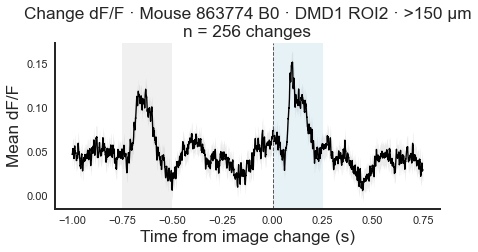

In [38]:
CHANGE_EXAMPLE=dict(mouse=863774,day="B0",dmd=1,roi=2)

r,s=select_roi_example(CHANGE_EXAMPLE)
t,y,sem,n_trials=mean_single_trial_dff(
    s,int(r["dmd"]),int(r["roi"]),"change"
)
c=DEPTH_COLORS[str(r["depth_group"])]

fig,ax=plt.subplots(figsize=(6.4,3.6))
ax.fill_between(t,y-sem,y+sem,color=".55",alpha=.18,lw=0)
ax.plot(t,y,color="black",lw=1.35)
ax.axvspan(
    -IMAGE_CYCLE_S,-IMAGE_CYCLE_S+IMAGE_WINDOW_S[1],
    color=".75",alpha=.22,lw=0
)
ax.axvspan(0,IMAGE_WINDOW_S[1],color=c,alpha=.18,lw=0)
ax.axvline(0,color=".35",lw=1,ls="--")
ax.set(
    xlabel="Time from image change (s)",
    ylabel="Mean dF/F",
    title=(
        f'Change dF/F · Mouse {r["subject_id"]} {r["session_label"]} · '
        f'DMD{int(r["dmd"])} ROI{int(r["roi"])} · {r["depth_group"]}\n'
        f'n = {n_trials} changes'
    ),
)
finish_axis(ax); fig.tight_layout()
save_figure(fig,os.path.join(SAVE_PATH,"change_example_dff"),formats=[".pdf"],dpi=300)
plt.show()


## Pre-change versus change response magnitude

Each point in the scatter is one neuron/session. The longitudinal panels show depth-group median ± IQR, with faint lines only for valid manually registered neurons observed across sessions.

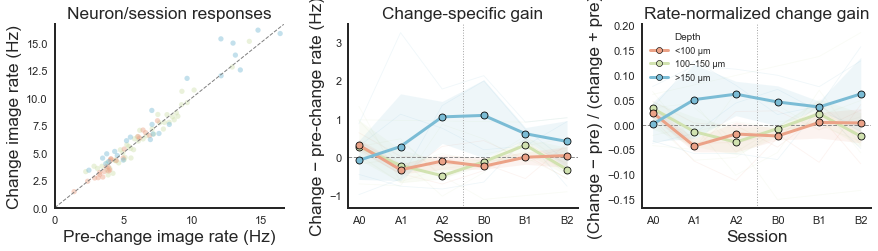

,subject_id,session_label,dmd,roi,depth_group,pre_change_rate_hz,change_rate_hz,change_delta_pre_hz,change_modulation_index,n_changes
0,852835,A0,1,0,<100 µm,6.169014,6.323944,0.154930,0.012401,284
1,852835,A0,1,1,<100 µm,6.422535,7.056338,0.633803,0.047022,284
2,852835,A0,1,2,<100 µm,6.605634,6.816901,0.211268,0.015740,284
3,852835,A0,1,3,<100 µm,6.056338,6.464789,0.408451,0.032621,284
49,863774,A0,2,0,100–150 µm,4.955882,5.000000,0.044118,0.004431,272
...,...,...,...,...,...,...,...,...,...,...
44,852835,B2,2,3,100–150 µm,8.845878,8.616487,-0.229391,-0.013136,279
85,863774,B2,1,0,>150 µm,2.483755,3.407942,0.924188,0.156863,277
86,863774,B2,1,1,>150 µm,12.101083,11.985560,-0.115523,-0.004796,277
87,863774,B2,1,2,>150 µm,3.480144,4.505415,1.025271,0.128391,277


In [59]:
fig,axs=plt.subplots(1,3,figsize=(12.3,3.6))

for group,g in change_metrics.groupby("depth_group",observed=True):
    axs[0].scatter(
        g["pre_change_rate_hz"],g["change_rate_hz"],
        s=28,color=DEPTH_COLORS[str(group)],alpha=.45,edgecolor="none",
        label=str(group)
    )
vals=np.r_[change_metrics["pre_change_rate_hz"],change_metrics["change_rate_hz"]]
upper=np.nanpercentile(vals[np.isfinite(vals)],99)*1.05 if np.isfinite(vals).any() else 1
lim=(0,max(upper,1e-6))
axs[0].plot(lim,lim,color=".5",ls="--",lw=1)
axs[0].set(
    xlim=lim,ylim=lim,
    xlabel="Pre-change image rate (Hz)",
    ylabel="Change image rate (Hz)",
    title="Neuron/session responses",
)
finish_axis(axs[0])

plot_longitudinal(
    axs[1],change_metrics,"change_delta_pre_hz",
    "Change − pre-change rate (Hz)"
)
axs[1].axhline(0,color=".55",lw=1,ls="--")
axs[1].set_title("Change-specific gain")

plot_longitudinal(
    axs[2],change_metrics,"change_modulation_index",
    "(Change − pre) / (change + pre)"
)
axs[2].axhline(0,color=".55",lw=1,ls="--")
# axs[2].set_ylim(-1.05,1.05)
axs[2].set_title("Rate-normalized change gain")
add_depth_legend(axs[2])

fig.tight_layout()
save_figure(fig,os.path.join(SAVE_PATH,"change_pre_vs_change"),formats=[".pdf"],dpi=300)
plt.show()

display(
    change_metrics.sort_values(["session_order","depth_um"])[[
        "subject_id","session_label","dmd","roi","depth_group",
        "pre_change_rate_hz","change_rate_hz","change_delta_pre_hz",
        "change_modulation_index","n_changes"
    ]]
)


## Change-aligned response shape across neurons

Garrett-style population view: event-aligned optical-spike firing rate is computed for every neuron, then summarized as the median ± IQR within each depth group for every session.

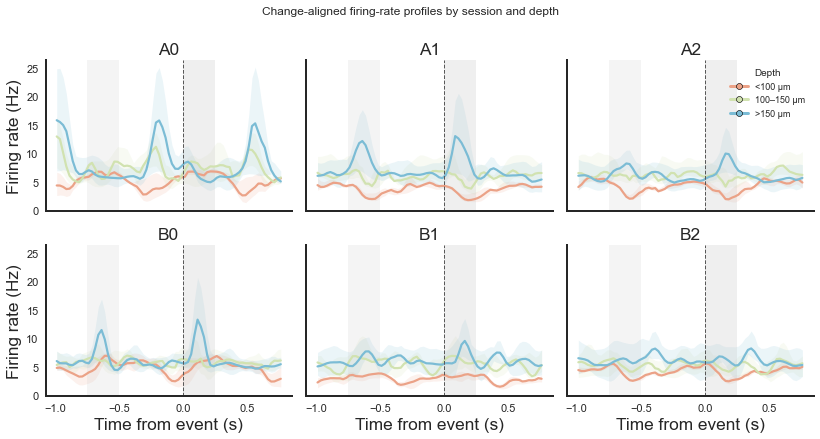

In [19]:
fig=plot_event_psth_grid(
    "is_change","retained_change_window",(-1.0,.75),
    [
        (-IMAGE_CYCLE_S,-IMAGE_CYCLE_S+IMAGE_WINDOW_S[1],".78",.18),
        (0,IMAGE_WINDOW_S[1],".78",.28),
    ],
    "Change-aligned firing-rate profiles by session and depth",
)
save_figure(
    fig,os.path.join(SAVE_PATH,"change_psth_session_depth"),
    formats=[".pdf"],dpi=300
)
plt.show()


# 5. Omission responses

The omission itself is quantified over the full **0–750 ms expected image cycle**, matching the omission timescale used in Garrett-style analyses. The preceding and first post-omission *actual images* are each quantified in their 250-ms image epochs. We retain four complementary quantities: omission − pre-omission, a rate-normalized omission index, within-omission ramping (late − early half), and post-omission image gain.

In [20]:
omission_rows=[]

for session in sessions[
    sessions["session_label"].astype(str).isin(SESSION_ORDER)
].itertuples(index=False):
    sid=str(session.session_id)
    ev=event_context[event_context["session_id"].astype(str).eq(sid)].copy()
    onset_map=ev.set_index("event_id")["onset_sec"]
    om=ev[
        ev["is_omission"].astype(bool)
        & ev["retained_omission_window"].astype(bool)
    ].copy()
    if om.empty: continue

    om["pre_onset_sec"]=om["previous_presented_event_id"].map(onset_map)
    om["post_onset_sec"]=om["next_presented_event_id"].map(onset_map)
    on=om["onset_sec"].to_numpy(float)
    pre=om["pre_onset_sec"].to_numpy(float)
    post=om["post_onset_sec"].to_numpy(float)

    for r in rois[
        rois["included"].astype(bool)
        & rois["session_id"].astype(str).eq(sid)
    ].itertuples(index=False):
        st=spike_lookup.get((sid,int(r.dmd),int(r.roi)),np.array([],float))
        z=om[["event_id","onset_sec","time_block"]].copy()
        z["pre_omission_rate_hz"]=finite_rates(st,pre,IMAGE_WINDOW_S)
        z["omission_rate_hz"]=finite_rates(st,on,(0,IMAGE_CYCLE_S))
        z["omission_early_rate_hz"]=finite_rates(st,on,(0,IMAGE_CYCLE_S/2))
        z["omission_late_rate_hz"]=finite_rates(
            st,on,(IMAGE_CYCLE_S/2,IMAGE_CYCLE_S)
        )
        z["post_omission_rate_hz"]=finite_rates(st,post,IMAGE_WINDOW_S)
        z["omission_delta_pre_hz"]=(
            z["omission_rate_hz"]-z["pre_omission_rate_hz"]
        )
        z["omission_ramp_hz"]=(
            z["omission_late_rate_hz"]-z["omission_early_rate_hz"]
        )
        z["post_omission_delta_pre_hz"]=(
            z["post_omission_rate_hz"]-z["pre_omission_rate_hz"]
        )
        z["post_minus_omission_hz"]=(
            z["post_omission_rate_hz"]-z["omission_rate_hz"]
        )
        metadata=dict(
            subject_id=str(r.subject_id),session_id=sid,
            session_label=str(r.session_label),session_order=int(r.session_order),
            dmd=int(r.dmd),roi=int(r.roi),cell_id=str(r.cell_id),
            global_cell_id=str(getattr(r,"global_cell_id","")),
            manually_registered=bool(getattr(r,"manually_registered",False)),
            depth_um=float(r.depth_um),depth_group=str(r.depth_group),
        )
        for k,v in metadata.items():
            z[k]=v
        omission_rows.append(z)

if not omission_rows:
    raise RuntimeError("No retained omission trials were available.")
omission_trial_df=pd.concat(omission_rows,ignore_index=True)

omission_metrics=(
    omission_trial_df.groupby(event_metric_keys,observed=True,dropna=False)
    .agg(
        pre_omission_rate_hz=("pre_omission_rate_hz","mean"),
        omission_rate_hz=("omission_rate_hz","mean"),
        omission_early_rate_hz=("omission_early_rate_hz","mean"),
        omission_late_rate_hz=("omission_late_rate_hz","mean"),
        omission_delta_pre_hz=("omission_delta_pre_hz","mean"),
        omission_ramp_hz=("omission_ramp_hz","mean"),
        post_omission_rate_hz=("post_omission_rate_hz","mean"),
        post_omission_delta_pre_hz=("post_omission_delta_pre_hz","mean"),
        post_minus_omission_hz=("post_minus_omission_hz","mean"),
        n_omissions=("event_id","size"),
    )
    .reset_index()
)
den=omission_metrics["omission_rate_hz"]+omission_metrics["pre_omission_rate_hz"]
omission_metrics["omission_modulation_index"]=np.where(
    den>0,omission_metrics["omission_delta_pre_hz"]/den,np.nan
)
display(omission_metrics.head())


,subject_id,session_id,session_label,session_order,dmd,roi,cell_id,global_cell_id,manually_registered,depth_um,...,omission_rate_hz,omission_early_rate_hz,omission_late_rate_hz,omission_delta_pre_hz,omission_ramp_hz,post_omission_rate_hz,post_omission_delta_pre_hz,post_minus_omission_hz,n_omissions,omission_modulation_index
0,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,46.75,...,7.017544,7.438596,6.596491,1.333333,-0.842105,6.736842,1.052632,-0.280702,19,0.104972
1,852835,852835_2026-07-23_14-27-27,A0,0,1,1,852835_C002,852835_C002,True,46.75,...,5.192982,8.280702,2.105263,-3.859649,-6.175439,8.631579,-0.421053,3.438596,19,-0.270936
2,852835,852835_2026-07-23_14-27-27,A0,0,1,2,852835_C001,852835_C001,True,46.75,...,10.245614,8.561404,11.929825,0.771930,3.368421,4.421053,-5.052632,-5.824561,19,0.039146
3,852835,852835_2026-07-23_14-27-27,A0,0,1,3,852835_C000,852835_C000,True,46.75,...,5.824561,6.456140,5.192982,1.403509,-1.263158,5.263158,0.842105,-0.561404,19,0.136986
4,852835,852835_2026-07-23_14-27-27,A0,0,2,0,852835_C006,852835_C006,True,120.50,...,11.859649,13.754386,9.964912,-4.561404,-3.789474,16.000000,-0.421053,4.140351,19,-0.161290


## Selectable mean dF/F omission example

Edit `OMISSION_EXAMPLE` to choose the example neuron. The light central span is the omitted 750-ms cycle; the depth-colored span marks the first actual image after the omission.

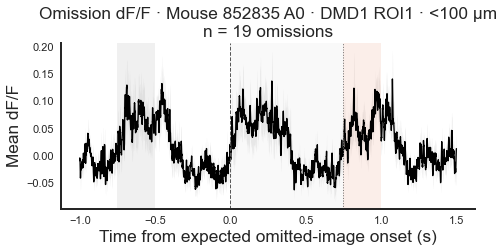

In [67]:
OMISSION_EXAMPLE=dict(mouse=852835,day="A0",dmd=1,roi=1)

r,s=select_roi_example(OMISSION_EXAMPLE)
t,y,sem,n_trials=mean_single_trial_dff(
    s,int(r["dmd"]),int(r["roi"]),"omission"
)
c=DEPTH_COLORS[str(r["depth_group"])]

fig,ax=plt.subplots(figsize=(6.8,3.6))
ax.fill_between(t,y-sem,y+sem,color=".55",alpha=.18,lw=0)
ax.plot(t,y,color="black",lw=1.35)
ax.axvspan(
    -IMAGE_CYCLE_S,-IMAGE_CYCLE_S+IMAGE_WINDOW_S[1],
    color=".75",alpha=.22,lw=0
)
ax.axvspan(0,IMAGE_CYCLE_S,color=".85",alpha=.14,lw=0)
ax.axvspan(
    IMAGE_CYCLE_S,IMAGE_CYCLE_S+IMAGE_WINDOW_S[1],
    color=c,alpha=.18,lw=0
)
ax.axvline(0,color=".35",lw=1,ls="--")
ax.axvline(IMAGE_CYCLE_S,color=".45",lw=1,ls=":")
ax.set(
    xlabel="Time from expected omitted-image onset (s)",
    ylabel="Mean dF/F",
    title=(
        f'Omission dF/F · Mouse {r["subject_id"]} {r["session_label"]} · '
        f'DMD{int(r["dmd"])} ROI{int(r["roi"])} · {r["depth_group"]}\n'
        f'n = {n_trials} omissions'
    ),
)
finish_axis(ax); fig.tight_layout()
save_figure(
    fig,os.path.join(SAVE_PATH,"omission_example_dff"),
    formats=[".pdf"],dpi=300
)
plt.show()


## Pre-omission, omission, ramping, and post-omission response magnitude

The scatter plots expose neuron-to-neuron heterogeneity directly. The longitudinal panels then ask whether omission enhancement/suppression, within-omission ramping, or the first post-omission image response changes systematically with session and soma depth.

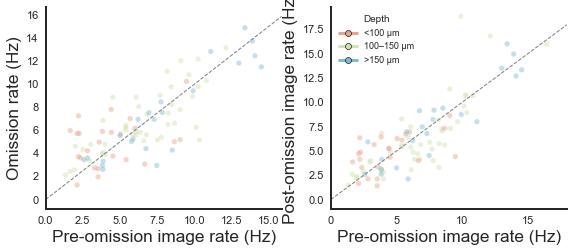

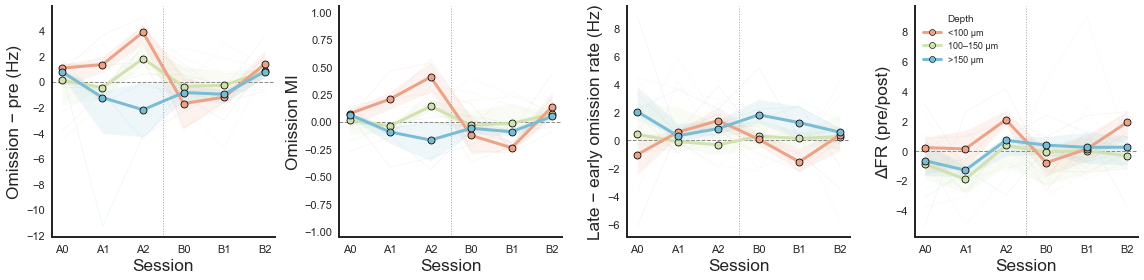

,subject_id,session_label,dmd,roi,depth_group,pre_omission_rate_hz,omission_rate_hz,omission_delta_pre_hz,omission_ramp_hz,post_omission_rate_hz,post_omission_delta_pre_hz,n_omissions
0,852835,A0,1,0,<100 µm,5.684211,7.017544,1.333333,-0.842105,6.736842,1.052632,19
1,852835,A0,1,1,<100 µm,9.052632,5.192982,-3.859649,-6.175439,8.631579,-0.421053,19
2,852835,A0,1,2,<100 µm,9.473684,10.245614,0.771930,3.368421,4.421053,-5.052632,19
3,852835,A0,1,3,<100 µm,4.421053,5.824561,1.403509,-1.263158,5.263158,0.842105,19
49,863774,A0,2,0,100–150 µm,3.851852,3.950617,0.098765,0.987654,2.962963,-0.888889,27
...,...,...,...,...,...,...,...,...,...,...,...,...
44,852835,B2,2,3,100–150 µm,10.260870,12.173913,1.913043,-0.695652,10.608696,0.347826,23
85,863774,B2,1,0,>150 µm,2.588235,3.450980,0.862745,0.313725,2.588235,0.000000,17
86,863774,B2,1,1,>150 µm,13.411765,14.901961,1.490196,0.941176,16.000000,2.588235,17
87,863774,B2,1,2,>150 µm,5.882353,5.254902,-0.627451,0.784314,2.117647,-3.764706,17


In [64]:
fig,axs=plt.subplots(1,2,figsize=(8.2,3.6))

for group,g in omission_metrics.groupby("depth_group",observed=True):
    c=DEPTH_COLORS[str(group)]
    axs[0].scatter(
        g["pre_omission_rate_hz"],g["omission_rate_hz"],
        s=28,color=c,alpha=.45,edgecolor="none"
    )
    axs[1].scatter(
        g["pre_omission_rate_hz"],g["post_omission_rate_hz"],
        s=28,color=c,alpha=.45,edgecolor="none"
    )

for ax,ycol,ylabel,title in [
    (axs[0],"omission_rate_hz","Omission rate (Hz)","Omission versus preceding image"),
    (axs[1],"post_omission_rate_hz","Post-omission image rate (Hz)",
     "Post-omission versus preceding image"),
]:
    vals=np.r_[omission_metrics["pre_omission_rate_hz"],omission_metrics[ycol]]
    upper=np.nanpercentile(vals[np.isfinite(vals)],99)*1.05 if np.isfinite(vals).any() else 1
    lim=(0,max(upper,1e-6))
    ax.plot(lim,lim,color=".5",ls="--",lw=1)
    ax.set(
        xlim=lim,
#         ylim=lim,
        xlabel="Pre-omission image rate (Hz)",
        ylabel=ylabel,
#         title=title
    )
    finish_axis(ax)

add_depth_legend(axs[1])
fig.tight_layout()
save_figure(
    fig,os.path.join(SAVE_PATH,"omission_response_scatter"),
    formats=[".pdf"],dpi=300
)
plt.show()

fig,axs=plt.subplots(1,4,figsize=(16,4))
plot_longitudinal(
    axs[0],omission_metrics,"omission_delta_pre_hz",
    "Omission − pre (Hz)"
)
# axs[0].set_title("Omission gain")

plot_longitudinal(
    axs[1],omission_metrics,"omission_modulation_index",
    "Omission MI"
)
axs[1].set_ylim(-1.05,1.05)
# axs[1].set_title("Normalized omission gain")

plot_longitudinal(
    axs[2],omission_metrics,"omission_ramp_hz",
    "Late − early omission rate (Hz)"
)
# axs[2].set_title("Within-omission ramp")

plot_longitudinal(
    axs[3],omission_metrics,"post_omission_delta_pre_hz",
    "\u0394FR (pre/post)"
)
# axs[3].set_title("Post-omission image gain")
add_depth_legend(axs[3])

for ax in axs:
    ax.axhline(0,color=".55",lw=1,ls="--")

fig.tight_layout()
save_figure(
    fig,os.path.join(SAVE_PATH,"omission_metrics_session_depth"),
    formats=[".pdf"],dpi=300
)
plt.show()

display(
    omission_metrics.sort_values(["session_order","depth_um"])[[
        "subject_id","session_label","dmd","roi","depth_group",
        "pre_omission_rate_hz","omission_rate_hz","omission_delta_pre_hz",
        "omission_ramp_hz","post_omission_rate_hz",
        "post_omission_delta_pre_hz","n_omissions"
    ]]
)


## Omission-aligned response shape across neurons

The 0–750 ms omission interval is shown explicitly, followed by the first post-omission image. As above, traces are neuron-level PSTHs summarized by depth group within each session.

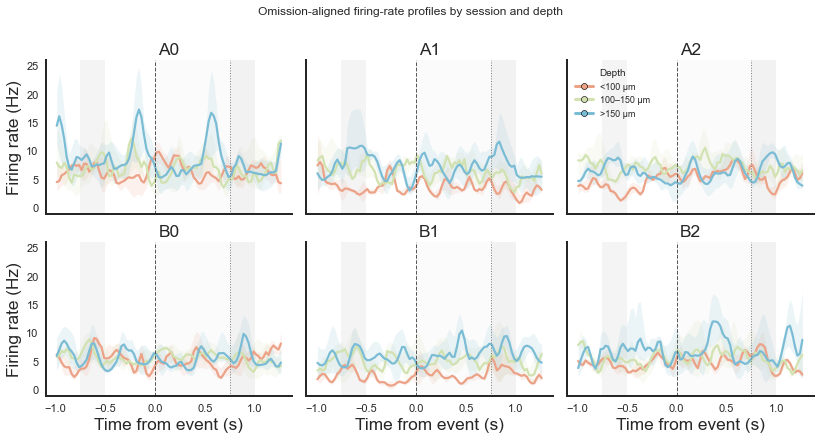

In [55]:
fig=plot_event_psth_grid(
    "is_omission","retained_omission_window",(-1.0,1.25),
    [
        (-IMAGE_CYCLE_S,-IMAGE_CYCLE_S+IMAGE_WINDOW_S[1],".78",.18),
        (0,IMAGE_CYCLE_S,".88",.12),
        (IMAGE_CYCLE_S,IMAGE_CYCLE_S+IMAGE_WINDOW_S[1],".78",.22),
    ],
    "Omission-aligned firing-rate profiles by session and depth",
)
for ax in fig.axes[:6]:
    ax.axvline(IMAGE_CYCLE_S,color=".5",lw=1,ls=":")
save_figure(
    fig,os.path.join(SAVE_PATH,"omission_psth_session_depth"),
    formats=[".pdf"],dpi=300
)
plt.show()
